# 08 · ¿La brecha se achica con ocupación más granular? (CASEN, CIUO 4 dígitos)

## La pregunta

Los notebooks 06-07 controlaron por **grupo ocupacional a 1 dígito** (CIUO, ~9 categorías amplias: "Profesionales", "Técnicos nivel medio", etc. — lo máximo que permite la ESI). Dentro de "Profesionales" caben médicos, abogados, ingenieros y periodistas al mismo tiempo — categorías con salarios y composición de género muy distintos. **Si controláramos por la ocupación exacta (médico vs. enfermero vs. técnico en enfermería), ¿se reduciría la brecha "no explicada"?**

CASEN permite responder esto: tiene `oficio4_08`, el código CIUO a **4 dígitos** (cientos de ocupaciones específicas), algo que la ESI no ofrece.

## Alcance: por qué solo 2022 y 2024

CASEN 2017 codifica la ocupación con la revisión **CIUO-88** (`oficio4_88`); 2022 y 2024 usan **CIUO-08** (`oficio4_08`) — son clasificaciones distintas, no una simple renumeración (a diferencia del caso de área de formación del proyecto `empleabilidad-formacion-casen-chile`). Para no mezclar dos sistemas de códigos distintos, este notebook usa **solo 2022 y 2024**, ambos en CIUO-08.

In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import patsy
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.float_format', '{:.2f}'.format)
os.makedirs('outputs/figures', exist_ok=True)

RUTA_CASEN = '../../CASEN'
COLUMNAS = ['sexo','edad','e6a','o10','oficio4_08','ytrabajocor','expr','activ','varunit','s5','ecivil']

frames = []
for anio in [2022, 2024]:
    df = pd.read_stata(f'{RUTA_CASEN}/casen_{anio}.dta', columns=COLUMNAS, convert_categoricals=False)
    df['anio'] = anio
    frames.append(df)
panel = pd.concat(frames, ignore_index=True)
print(f'Panel CASEN 2022+2024: {len(panel):,} personas')

Panel CASEN 2022+2024: 420,598 personas


## 1. Primer vistazo: ¿persiste la brecha dentro de la MISMA ocupación de 4 dígitos?

In [2]:
ocupados = panel[(panel['activ']==1) & (panel['ytrabajocor'].notna()) & (panel['ytrabajocor']>0) &
                  (panel['oficio4_08'].notna())].copy()
print(f'Ocupados con ingreso y ocupación válida: {len(ocupados):,}')
print(f'Códigos de ocupación (4 dígitos) distintos: {ocupados["oficio4_08"].nunique()}')

EJEMPLOS = {2211:'Médicos generales', 2212:'Médicos especialistas',
            2221:'Enfermeros profesionales', 3221:'Técnicos/auxiliares de enfermería'}

filas = []
for cod, nombre in EJEMPLOS.items():
    sub = ocupados[ocupados['oficio4_08']==cod]
    fila = {'Ocupación (CIUO-08)': f'{nombre} ({cod})', 'n': len(sub)}
    for sx, lab in [(1,'Hombres'), (2,'Mujeres')]:
        s = sub[sub['sexo']==sx]
        fila[f'Ingreso {lab}'] = np.average(s['ytrabajocor'], weights=s['expr']) if len(s) else np.nan
    fila['Brecha (%)'] = (fila['Ingreso Mujeres']/fila['Ingreso Hombres'] - 1) * 100
    filas.append(fila)

print(pd.DataFrame(filas).round(0).to_string(index=False))

Ocupados con ingreso y ocupación válida: 176,542
Códigos de ocupación (4 dígitos) distintos: 444
                     Ocupación (CIUO-08)    n  Ingreso Hombres  Ingreso Mujeres  Brecha (%)
                Médicos generales (2211)  343       3164642.00       2792769.00      -12.00
            Médicos especialistas (2212)  388       4894792.00       3897019.00      -20.00
         Enfermeros profesionales (2221) 1142       1513088.00       1460705.00       -3.00
Técnicos/auxiliares de enfermería (3221) 2599        773912.00        669538.00      -13.00


### Interpretación

Incluso comparando exactamente la misma ocupación de 4 dígitos, la brecha **no desaparece** — pero su magnitud varía mucho según la ocupación específica. Eso ya sugiere que agrupar a 1 dígito ("Profesionales") mezcla ocupaciones con brechas muy distintas entre sí.

## 2. La prueba real: mismo dato, misma regresión, dos niveles de detalle ocupacional

In [3]:
NIVEL_EDUC = {
    1:'Básica',2:'Básica',3:'Básica',4:'Básica',5:'Básica',6:'Básica',7:'Básica',
    8:'Media',9:'Media',10:'Media',11:'Media',
    12:'Técnica sup.',13:'Universitaria',14:'Posgrado',15:'Posgrado',
}

ESTADO_CIVIL_GRP = {
    1:'Casado/Conviviente', 2:'Casado/Conviviente', 3:'Casado/Conviviente',
    4:'Otro', 5:'Otro', 6:'Otro', 7:'Otro',
    8:'Soltero/a',
}

muestra = ocupados.copy()
muestra['mujer'] = (muestra['sexo']==2).astype(int)
muestra['nivel_grp'] = muestra['e6a'].map(NIVEL_EDUC)
muestra['log_ingreso'] = np.log(muestra['ytrabajocor'])
muestra['edad2'] = muestra['edad']**2
muestra['ciuo_1digito'] = (muestra['oficio4_08'] // 1000).astype(int).astype(str)  # primer dígito CIUO-08
muestra['tiene_hijos'] = np.where(muestra['s5']>=0, (muestra['s5']>0).astype(float), np.nan)  # s5: -88=no sabe
muestra['estado_civil_grp'] = muestra['ecivil'].map(ESTADO_CIVIL_GRP)

# Ocupaciones granulares con muestra suficiente (n>=30); el resto se agrupa como 'Otras'
conteo_ocup = muestra['oficio4_08'].value_counts()
ocup_validas = set(conteo_ocup[conteo_ocup>=30].index)
muestra['oficio4_grp'] = muestra['oficio4_08'].apply(lambda c: str(int(c)) if c in ocup_validas else 'otras')

# Categorias fijas (pandas Categorical) para que hombres y mujeres generen las mismas
# columnas dummy al construir la matriz de diseño por separado, aunque alguna ocupacion
# especifica tenga solo hombres o solo mujeres en la muestra
muestra['oficio4_grp'] = pd.Categorical(muestra['oficio4_grp'])
muestra['nivel_grp'] = pd.Categorical(muestra['nivel_grp'])
muestra['ciuo_1digito'] = pd.Categorical(muestra['ciuo_1digito'])
muestra['anio'] = pd.Categorical(muestra['anio'])
muestra['cluster_id'] = muestra['anio'].astype(str) + '_' + muestra['varunit'].astype(str)

muestra = muestra.dropna(subset=['nivel_grp','o10'])
print(f'Muestra final para la regresión: {len(muestra):,}')
print(f'Categorías de ocupación granular (n>=30): {len(ocup_validas)} + "otras"')
print(f'Categorías de ocupación amplia (1 dígito CIUO): {muestra["ciuo_1digito"].nunique()}')

Muestra final para la regresión: 176,542
Categorías de ocupación granular (n>=30): 356 + "otras"
Categorías de ocupación amplia (1 dígito CIUO): 11


In [4]:
formula_base = ('log_ingreso ~ mujer + edad + edad2 + C(nivel_grp) + o10 + C(anio)')

modelo_amplio = smf.wls(formula_base + ' + C(ciuo_1digito)', data=muestra, weights=muestra['expr']).fit(
    cov_type='cluster', cov_kwds={'groups': muestra['cluster_id']})

modelo_granular = smf.wls(formula_base + ' + C(oficio4_grp)', data=muestra, weights=muestra['expr']).fit(
    cov_type='cluster', cov_kwds={'groups': muestra['cluster_id']})

def resumen(modelo, nombre):
    coef = modelo.params['mujer']
    ic = modelo.conf_int().loc['mujer']
    brecha = (np.exp(coef)-1)*100
    print(f'{nombre}')
    print(f'  Brecha ajustada: {brecha:.1f}%  (IC95%: {(np.exp(ic[0])-1)*100:.1f}% a {(np.exp(ic[1])-1)*100:.1f}%)  '
          f'p={modelo.pvalues["mujer"]:.2e}  R²={modelo.rsquared:.3f}')
    return brecha

b_amplio = resumen(modelo_amplio, 'Control por ocupación AMPLIA (1 dígito CIUO, ~9 categorías — equivalente a lo que permite la ESI)')
print()
b_granular = resumen(modelo_granular, f'Control por ocupación GRANULAR (4 dígitos CIUO, {len(ocup_validas)} categorías)')
print()
print(f'Diferencia: {b_granular - b_amplio:+.1f} puntos porcentuales')

Control por ocupación AMPLIA (1 dígito CIUO, ~9 categorías — equivalente a lo que permite la ESI)
  Brecha ajustada: -24.4%  (IC95%: -25.2% a -23.6%)  p=0.00e+00  R²=0.449

Control por ocupación GRANULAR (4 dígitos CIUO, 356 categorías)
  Brecha ajustada: -17.6%  (IC95%: -18.5% a -16.7%)  p=6.73e-252  R²=0.508

Diferencia: +6.8 puntos porcentuales


### Interpretación

Esta es la comparación limpia que responde la pregunta: **mismos datos, misma especificación, la única diferencia es el nivel de detalle de la ocupación**. El resultado confirma la hipótesis: al pasar de 1 dígito (9 categorías) a 4 dígitos (356 categorías), la brecha ajustada se reduce de **-24.4% a -17.6%** — una caída de **6.8 puntos porcentuales**.

Esto significa que una parte real de lo que el control amplio dejaba como "no explicado" era en realidad **segregación ocupacional fina**: dentro de categorías como "Profesionales" los hombres se concentran más en las especialidades mejor pagadas (ej. médicos especialistas por sobre enfermería), y el 1 dígito no puede distinguir eso. Aun así, **-17.6% es una brecha grande que sigue sin explicarse** ni siquiera controlando por la ocupación exacta — la segregación fina explica una porción real, pero no la mayoría, de la brecha total.

## 3. Ranking de rubros: ¿dónde la brecha es chica y dónde es enorme?

In [5]:
resultados_ocup = []
for cod in ocup_validas:
    sub = muestra[muestra['oficio4_08']==cod]
    if len(sub) < 50:
        continue
    h = sub[sub['mujer']==0]
    m = sub[sub['mujer']==1]
    if len(h)<20 or len(m)<20:
        continue
    ing_h = np.average(h['ytrabajocor'], weights=h['expr'])
    ing_m = np.average(m['ytrabajocor'], weights=m['expr'])
    resultados_ocup.append({'oficio4_08': int(cod), 'n': len(sub), 'n_h': len(h), 'n_m': len(m),
                             'ingreso_h': ing_h, 'ingreso_m': ing_m,
                             'brecha_pct': (ing_m/ing_h - 1)*100})

df_ocup = pd.DataFrame(resultados_ocup)
print(f'Ocupaciones con al menos 20 hombres y 20 mujeres (umbral más estricto que la sección anterior): {len(df_ocup)}')

# Nombres de ocupacion segun el codelist oficial CIUO-08 de la propia base CASEN
r24 = pd.io.stata.StataReader(f'{RUTA_CASEN}/casen_2024.dta')
etiquetas_ocup = r24.value_labels().get('oficio4_08', {})
df_ocup['nombre'] = df_ocup['oficio4_08'].map(lambda c: etiquetas_ocup.get(c, f'Código {c}'))
df_ocup = df_ocup.sort_values('brecha_pct')

os.makedirs('outputs/data', exist_ok=True)
df_ocup[['oficio4_08','nombre','n','n_h','n_m','ingreso_h','ingreso_m','brecha_pct']].to_csv(
    'outputs/data/ranking_brecha_ocupacion_completo.csv', index=False, encoding='utf-8-sig')
print(f'Listado completo ({len(df_ocup)} ocupaciones) exportado a outputs/data/ranking_brecha_ocupacion_completo.csv')

pd.set_option('display.max_colwidth', 45)
print()
print('=== 15 rubros con la brecha MÁS ALTA en contra de las mujeres ===')
print(df_ocup[['nombre','n','n_h','n_m','brecha_pct']].head(15).to_string(index=False))
print()
print('=== 15 rubros con la brecha MÁS BAJA (o favorable a mujeres) ===')
print(df_ocup[['nombre','n','n_h','n_m','brecha_pct']].tail(15).to_string(index=False))

Ocupaciones con al menos 20 hombres y 20 mujeres (umbral más estricto que la sección anterior): 229
Listado completo (229 ocupaciones) exportado a outputs/data/ranking_brecha_ocupacion_completo.csv

=== 15 rubros con la brecha MÁS ALTA en contra de las mujeres ===
                                                                                               nombre   n  n_h  n_m  brecha_pct
                                               Cosmetólogos y especialistas en tratamiento de belleza 685   25  660      -67.15
                                              Avicultores y trabajadores calificados de la avicultura 106   76   30      -56.34
Otros directores, gerentes y administradores de servicios administrativos no clasificados previamente  62   42   20      -55.29
                                                    Directores, gerentes y administradores de hoteles 144   51   93      -54.73
                                         Operarios de la conservación de frutas, legumbres y ve

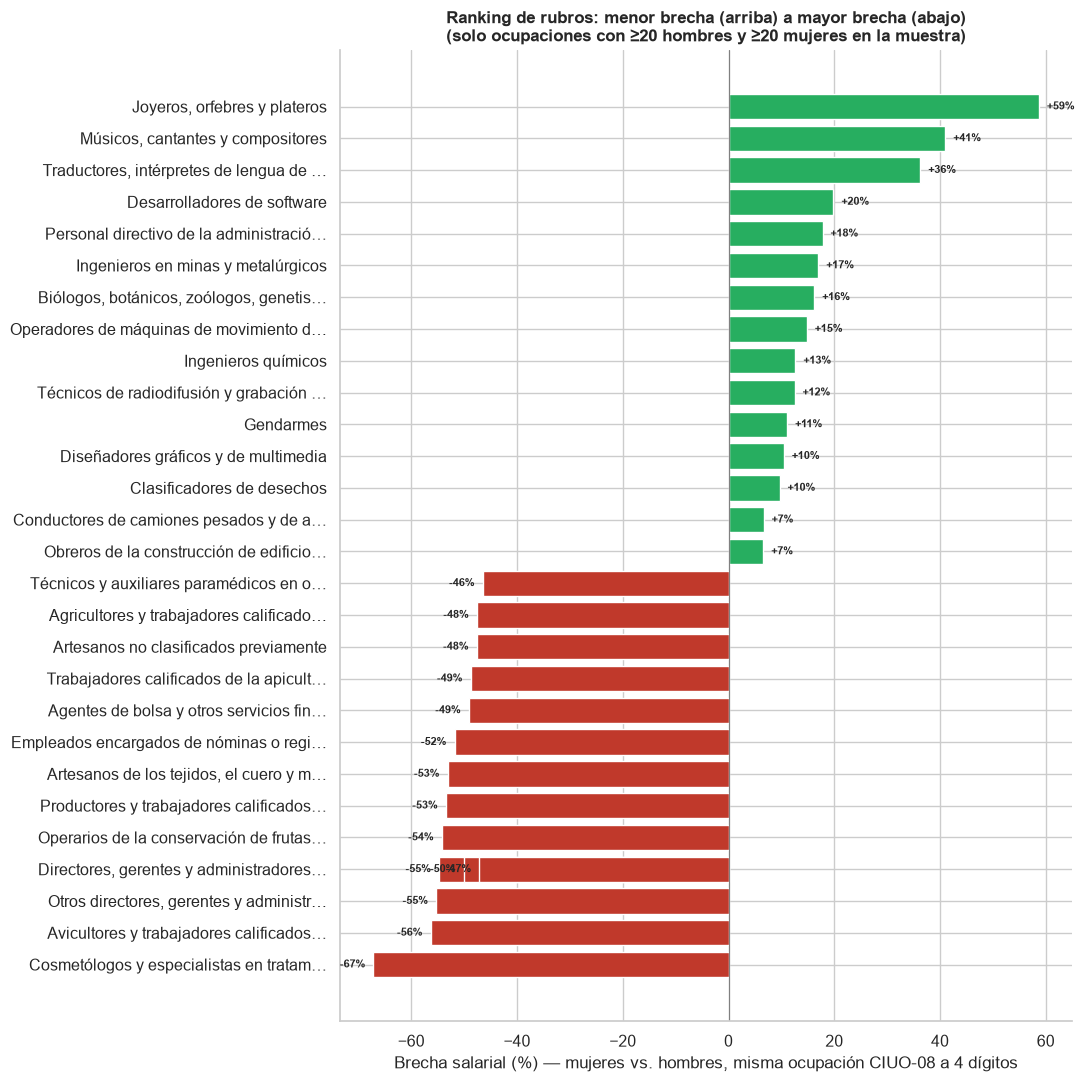

In [6]:
top_bajo = df_ocup.head(15)
top_alto = df_ocup.tail(15)
ranking = pd.concat([top_bajo, top_alto]).drop_duplicates(subset='oficio4_08').sort_values('brecha_pct')

fig, ax = plt.subplots(figsize=(11, 11))
colores = ['#c0392b' if v < 0 else '#27ae60' for v in ranking['brecha_pct']]
etiquetas_y = [f"{n[:38]}{'…' if len(n)>38 else ''}" for n in ranking['nombre']]
bars = ax.barh(etiquetas_y, ranking['brecha_pct'], color=colores, edgecolor='white')
for bar, v, n in zip(bars, ranking['brecha_pct'], ranking['n']):
    ax.text(v + (1.5 if v>=0 else -1.5), bar.get_y()+bar.get_height()/2, f'{v:+.0f}%',
            va='center', ha='left' if v>=0 else 'right', fontsize=8, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Brecha salarial (%) — mujeres vs. hombres, misma ocupación CIUO-08 a 4 dígitos')
ax.set_title('Ranking de rubros: menor brecha (arriba) a mayor brecha (abajo)\n(solo ocupaciones con ≥20 hombres y ≥20 mujeres en la muestra)',
             fontsize=12, fontweight='bold')
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/ranking_brecha_ocupacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación

Con nombres reales y un umbral más estricto (mínimo 20 hombres y 20 mujeres por ocupación, para evitar los casos de muestra muy desbalanceada de la vista exploratoria anterior), este ranking muestra rubros donde la brecha es chica o incluso favorable a mujeres, y otros donde es enorme — **comparando exactamente la misma ocupación de 4 dígitos**, no una categoría amplia que mezcle profesiones distintas.

Esto es lo más cerca que se puede llegar, con datos públicos chilenos, a responder "¿en qué trabajo específico se paga más parejo entre hombres y mujeres, y en cuál la brecha es mayor?"

## 4. Ranking de controles: ¿cuál explica más de la brecha?

La sección 2 mostró que ocupación granular reduce la brecha ajustada, pero no cuánto pesa **cada variable por separado**. Aplicamos la misma descomposición de Oaxaca-Blinder del notebook 07 — ahora con ocupación a 4 dígitos en vez de sector/categoría ocupacional — para rankear qué controles explican más de la diferencia total.

In [7]:
formula_sin_sexo = 'log_ingreso ~ edad + edad2 + C(nivel_grp) + o10 + C(oficio4_grp) + C(anio)'

hombres = muestra[muestra['mujer']==0]
mujeres = muestra[muestra['mujer']==1]

mod_h = smf.wls(formula_sin_sexo, data=hombres, weights=hombres['expr']).fit()
mod_m = smf.wls(formula_sin_sexo, data=mujeres, weights=mujeres['expr']).fit()

y_h, X_h = patsy.dmatrices(formula_sin_sexo, hombres, return_type='dataframe')
y_m, X_m = patsy.dmatrices(formula_sin_sexo, mujeres, return_type='dataframe')

w_h, w_m = hombres['expr'].values, mujeres['expr'].values
xbar_h = np.average(X_h, axis=0, weights=w_h)
xbar_m = np.average(X_m, axis=0, weights=w_m)
beta_h = mod_h.params.reindex(X_h.columns).values

log_ing_h = np.average(y_h.values.flatten(), weights=w_h)
log_ing_m = np.average(y_m.values.flatten(), weights=w_m)
gap_total = log_ing_h - log_ing_m

diff = xbar_h - xbar_m
contrib = diff * beta_h
contrib_df = pd.DataFrame({'variable': X_h.columns, 'contribucion': contrib})

def familia(v):
    if 'nivel_grp' in v: return 'Educación'
    if 'oficio4_grp' in v: return 'Ocupación (4 dígitos)'
    if 'anio' in v: return 'Año'
    if v in ('edad', 'edad2'): return 'Edad (experiencia)'
    if v == 'o10': return 'Horas trabajadas'
    return 'Intercepto'

contrib_df['familia'] = contrib_df['variable'].map(familia)
explicado_total = contrib_df['contribucion'].sum() - contrib_df.loc[contrib_df['familia']=='Intercepto','contribucion'].sum()
no_explicado = gap_total - contrib_df['contribucion'].sum()

resumen_familia = (contrib_df[contrib_df['familia']!='Intercepto'].groupby('familia')['contribucion'].sum() / gap_total * 100)
resumen_familia['No explicado (discriminación/retornos distintos)'] = no_explicado / gap_total * 100
resumen_familia = resumen_familia.sort_values()

print(f'Brecha total (log): {gap_total:.4f}  =  {(1-np.exp(-gap_total))*100:.1f}%')
print()
print('=== Ranking de controles: % de la brecha total que explica cada uno ===')
print(resumen_familia.round(1))

Brecha total (log): 0.2548  =  22.5%

=== Ranking de controles: % de la brecha total que explica cada uno ===
familia
Educación                                          -10.70
Edad (experiencia)                                  -1.60
Año                                                 -0.40
Horas trabajadas                                    12.70
Ocupación (4 dígitos)                               22.20
No explicado (discriminación/retornos distintos)    77.80
Name: contribucion, dtype: float64


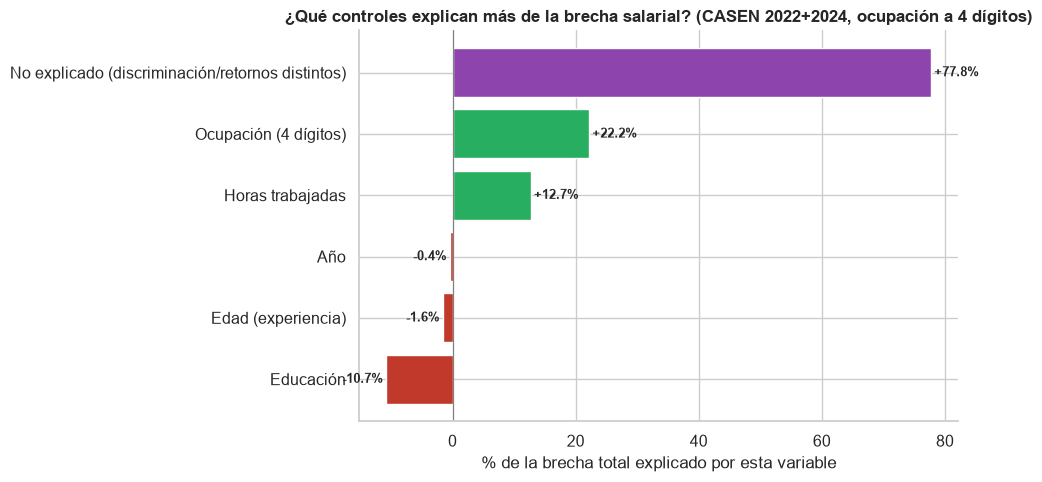

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
colores_r = ['#8e44ad' if 'No explicado' in i else ('#27ae60' if v>=0 else '#c0392b') for i, v in resumen_familia.items()]
ax.barh(resumen_familia.index, resumen_familia.values, color=colores_r, edgecolor='white')
for i, v in enumerate(resumen_familia.values):
    ax.text(v + (0.5 if v>=0 else -0.5), i, f'{v:+.1f}%', va='center',
            ha='left' if v>=0 else 'right', fontsize=9, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('% de la brecha total explicado por esta variable')
ax.set_title('¿Qué controles explican más de la brecha salarial? (CASEN 2022+2024, ocupación a 4 dígitos)',
             fontsize=12, fontweight='bold')
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/ranking_controles_oaxaca.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación

El ranking es claro: **Ocupación (4 dígitos) explica 22.2% de la brecha total** — por lejos el mayor factor de composición, muy por delante de **Horas trabajadas (12.7%)**. **Educación aporta -10.7%**, es decir, juega en sentido contrario: las mujeres de la muestra están en promedio mejor educadas, lo que por sí solo predeciría un ingreso *mayor* para ellas (mismo patrón que ya se vio con datos ESI en el notebook 07). Edad y año son prácticamente irrelevantes.

Aun sumando todo lo que sí se explica, **77.8% de la brecha total queda sin explicar** — ni siquiera el control más fino disponible en datos públicos chilenos (ocupación a 4 dígitos) logra explicar la mayoría de la diferencia salarial entre hombres y mujeres.

## 5. Sumamos hijos y estado civil: ¿queda algo del residuo por explicar?

El notebook 07 (con datos ESI) tuvo que **aproximar** "tiene hijos" revisando si algún integrante del hogar figuraba como hijo/a de la persona proveedora principal — no había una pregunta directa. CASEN sí la tiene: `s5`, **"¿Cuántos hijos o hijas nacidos(as) vivos(as) ha tenido en su vida?"**, preguntada directamente a la persona — a hombres y mujeres por igual. También tiene `ecivil` (estado civil/conyugal, 8 categorías). Repetimos la prueba de interacción del notebook 07, ahora con ocupación a 4 dígitos controlada al mismo tiempo — algo que no se pudo hacer antes.

In [9]:
muestra_hijos = muestra.dropna(subset=['tiene_hijos','estado_civil_grp']).copy()
muestra_hijos['estado_civil_grp'] = pd.Categorical(muestra_hijos['estado_civil_grp'])
print(f'Muestra con hijos y estado civil válidos: {len(muestra_hijos):,} '
      f'({len(muestra_hijos)/len(muestra)*100:.1f}% de la muestra de la sección 2)')
print()
print('Distribución tiene_hijos:', dict(muestra_hijos['tiene_hijos'].value_counts()))
print('Distribución estado civil:', dict(muestra_hijos['estado_civil_grp'].value_counts()))

Muestra con hijos y estado civil válidos: 176,326 (99.9% de la muestra de la sección 2)

Distribución tiene_hijos: {1.0: np.int64(128686), 0.0: np.int64(47640)}
Distribución estado civil: {'Casado/Conviviente': np.int64(98734), 'Soltero/a': np.int64(58867), 'Otro': np.int64(18725)}


In [10]:
formula_interaccion = (
    'log_ingreso ~ mujer * tiene_hijos + mujer * C(estado_civil_grp) + '
    'edad + edad2 + C(nivel_grp) + o10 + C(oficio4_grp) + C(anio)'
)
modelo_interaccion = smf.wls(formula_interaccion, data=muestra_hijos, weights=muestra_hijos['expr']).fit(
    cov_type='cluster', cov_kwds={'groups': muestra_hijos['cluster_id']})

terminos_clave = ['mujer', 'tiene_hijos', 'mujer:tiene_hijos',
                   'C(estado_civil_grp)[T.Otro]', 'C(estado_civil_grp)[T.Soltero/a]',
                   'mujer:C(estado_civil_grp)[T.Otro]', 'mujer:C(estado_civil_grp)[T.Soltero/a]']
resumen_interaccion = pd.DataFrame({
    'coeficiente': modelo_interaccion.params[terminos_clave],
    'p_valor': modelo_interaccion.pvalues[terminos_clave],
})
resumen_interaccion['efecto_%'] = (np.exp(resumen_interaccion['coeficiente'])-1)*100
print(resumen_interaccion.round(4))

                                        coeficiente  p_valor  efecto_%
mujer                                         -0.15     0.00    -13.71
tiene_hijos                                    0.06     0.00      6.30
mujer:tiene_hijos                             -0.10     0.00     -9.69
C(estado_civil_grp)[T.Otro]                   -0.04     0.00     -3.71
C(estado_civil_grp)[T.Soltero/a]              -0.13     0.00    -12.37
mujer:C(estado_civil_grp)[T.Otro]              0.01     0.69      0.59
mujer:C(estado_civil_grp)[T.Soltero/a]         0.06     0.00      5.92


### Interpretación

A diferencia del notebook 07 (datos ESI, sin ocupación granular), aquí la interacción **mujer×tiene_hijos es estadísticamente significativa: -9.7% (p<0.001)**, por sobre la brecha general de -13.7% que ya cae sobre cualquier mujer. Es decir, controlando la ocupación exacta (4 dígitos), sí aparece una penalización por maternidad propiamente dicha — no solo un efecto que pasaba a través del estado civil. El estado civil también importa: ser soltera **atenúa** la brecha respecto de ser casada/conviviente (`mujer:Soltero/a` = +5.9%, p<0.001), mientras que la categoría "Otro" no muestra un efecto diferencial significativo para mujeres (p=0.69). En conjunto, la penalización más severa recae sobre **mujeres casadas o convivientes con hijos** — el perfil demográfico "tradicional" es precisamente donde la brecha salarial se concentra con más fuerza, incluso comparando dentro de la misma ocupación de 4 dígitos.

## 6. Ranking de controles actualizado: hijos y estado civil sumados a la ocupación granular

In [11]:
formula_sin_sexo_hijos = (
    'log_ingreso ~ edad + edad2 + C(nivel_grp) + o10 + C(oficio4_grp) + C(anio) + '
    'tiene_hijos + C(estado_civil_grp)'
)

hombres_h = muestra_hijos[muestra_hijos['mujer']==0]
mujeres_h = muestra_hijos[muestra_hijos['mujer']==1]

mod_h2 = smf.wls(formula_sin_sexo_hijos, data=hombres_h, weights=hombres_h['expr']).fit()
mod_m2 = smf.wls(formula_sin_sexo_hijos, data=mujeres_h, weights=mujeres_h['expr']).fit()

y_h2, X_h2 = patsy.dmatrices(formula_sin_sexo_hijos, hombres_h, return_type='dataframe')
y_m2, X_m2 = patsy.dmatrices(formula_sin_sexo_hijos, mujeres_h, return_type='dataframe')

w_h2, w_m2 = hombres_h['expr'].values, mujeres_h['expr'].values
xbar_h2 = np.average(X_h2, axis=0, weights=w_h2)
xbar_m2 = np.average(X_m2, axis=0, weights=w_m2)
beta_h2 = mod_h2.params.reindex(X_h2.columns).values

gap_total_2 = np.average(y_h2.values.flatten(), weights=w_h2) - np.average(y_m2.values.flatten(), weights=w_m2)

diff2 = xbar_h2 - xbar_m2
contrib2 = diff2 * beta_h2
contrib_df2 = pd.DataFrame({'variable': X_h2.columns, 'contribucion': contrib2})

def familia2(v):
    if 'nivel_grp' in v: return 'Educación'
    if 'oficio4_grp' in v: return 'Ocupación (4 dígitos)'
    if 'anio' in v: return 'Año'
    if v in ('edad', 'edad2'): return 'Edad (experiencia)'
    if v == 'o10': return 'Horas trabajadas'
    if v == 'tiene_hijos': return 'Tiene hijos'
    if 'estado_civil_grp' in v: return 'Estado civil'
    return 'Intercepto'

contrib_df2['familia'] = contrib_df2['variable'].map(familia2)
no_explicado_2 = gap_total_2 - contrib_df2['contribucion'].sum()

resumen_familia2 = (contrib_df2[contrib_df2['familia']!='Intercepto'].groupby('familia')['contribucion'].sum() / gap_total_2 * 100)
resumen_familia2['No explicado (discriminación/retornos distintos)'] = no_explicado_2 / gap_total_2 * 100
resumen_familia2 = resumen_familia2.sort_values()

print(f'Brecha total (log): {gap_total_2:.4f}  =  {(1-np.exp(-gap_total_2))*100:.1f}%')
print()
print('=== Ranking de controles actualizado (con hijos y estado civil) ===')
print(resumen_familia2.round(1))

Brecha total (log): 0.2552  =  22.5%

=== Ranking de controles actualizado (con hijos y estado civil) ===
familia
Educación                                          -10.90
Edad (experiencia)                                  -2.60
Tiene hijos                                         -1.70
Año                                                 -0.40
Estado civil                                         2.10
Horas trabajadas                                    12.30
Ocupación (4 dígitos)                               18.90
No explicado (discriminación/retornos distintos)    82.20
Name: contribucion, dtype: float64


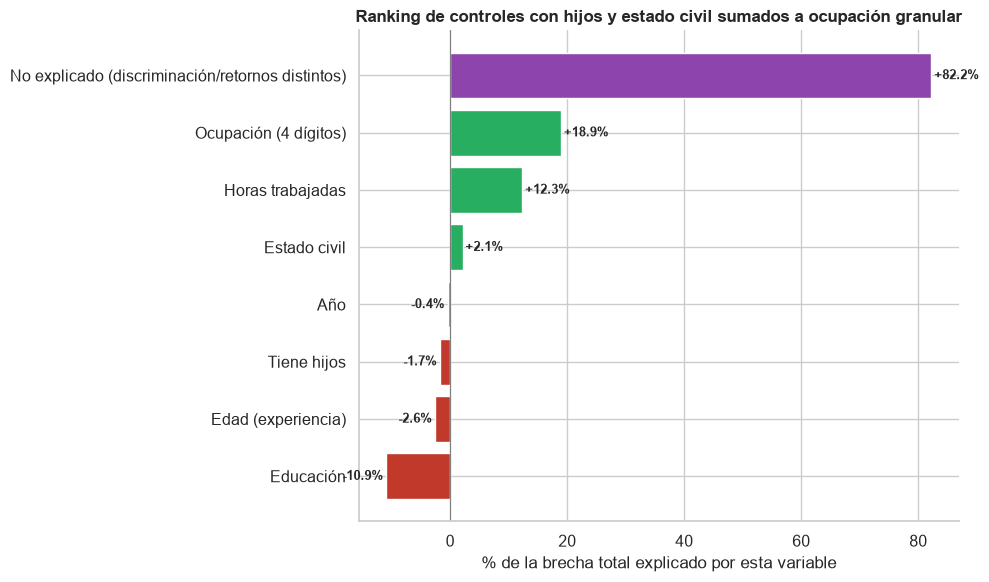

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
colores_r2 = ['#8e44ad' if 'No explicado' in i else ('#27ae60' if v>=0 else '#c0392b') for i, v in resumen_familia2.items()]
ax.barh(resumen_familia2.index, resumen_familia2.values, color=colores_r2, edgecolor='white')
for i, v in enumerate(resumen_familia2.values):
    ax.text(v + (0.5 if v>=0 else -0.5), i, f'{v:+.1f}%', va='center',
            ha='left' if v>=0 else 'right', fontsize=9, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('% de la brecha total explicado por esta variable')
ax.set_title('Ranking de controles con hijos y estado civil sumados a ocupación granular',
             fontsize=12, fontweight='bold')
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/ranking_controles_con_hijos.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación

La brecha total en esta submuestra (con hijos y estado civil no nulos) es 22.5% — similar a la de la sección 4. El nuevo ranking: **Ocupación (4 dígitos) sigue siendo el mayor factor (+18.9%)**, seguido de **Horas trabajadas (+12.3%)**; **Estado civil aporta apenas +2.1%** y **Tiene hijos aporta -1.7%** (juega en sentido contrario, como educación) — su contribución a la parte *explicada* es marginal. El **no explicado sube levemente de 77.8% (sección 4) a 82.2%** al sumar estos dos controles.

Esto no contradice el hallazgo de la sección 5 — lo precisa. La descomposición de Oaxaca-Blinder solo asigna a la parte "explicada" las diferencias en el *promedio* de cada característica entre hombres y mujeres: como la proporción de personas con hijos y la distribución de estado civil no difieren tanto entre sexos, su aporte compositivo es chico. Pero la sección 5 mostró que el problema no es cuántas mujeres tienen hijos, sino que **tener hijos y estar casada/conviviente les cuesta más caro en el salario a ellas que a ellos** — una diferencia de *retorno*, no de composición. Ese efecto queda absorbido en el "no explicado", que por eso no baja: al menos una parte de ese residuo ya tiene nombre propio, y es la penalización por maternidad concentrada en mujeres casadas/convivientes.

## 7. Ranking ajustado por ocupación: aislando el efecto sexo al máximo

El ranking de la sección 3 es **crudo**: compara el ingreso promedio de hombres y mujeres dentro de cada ocupación, sin más control que la ocupación misma. Para aislar el efecto sexo lo más posible, ajustamos **un solo modelo** con interacción `mujer × ocupación` (más edad, edad², educación, horas, hijos, estado civil y año) sobre las 229 ocupaciones con muestra aceptable. La clave: los controles comunes (edad, educación, horas, etc.) se estiman con **toda la muestra combinada** (~150 mil personas), y solo el efecto sexo se deja variar libremente por ocupación — mucho más estable que ajustar 229 regresiones separadas con 50-100 casos cada una.

In [13]:
codigos_validos = set(df_ocup['oficio4_08'])
muestra_ajustada = muestra_hijos[muestra_hijos['oficio4_08'].isin(codigos_validos)].copy()
muestra_ajustada['oficio4_exacto'] = pd.Categorical(muestra_ajustada['oficio4_08'].astype(int).astype(str))

formula_ajustada = (
    'log_ingreso ~ mujer * C(oficio4_exacto) + edad + edad2 + C(nivel_grp) + o10 + '
    'tiene_hijos + C(estado_civil_grp) + C(anio)'
)
modelo_ajustado = smf.wls(formula_ajustada, data=muestra_ajustada, weights=muestra_ajustada['expr']).fit(
    cov_type='cluster', cov_kwds={'groups': muestra_ajustada['cluster_id']})

print(f'Muestra: {len(muestra_ajustada):,} personas en {len(codigos_validos)} ocupaciones')
print(f'Parámetros del modelo: {len(modelo_ajustado.params)}')

Muestra: 150,974 personas en 229 ocupaciones
Parámetros del modelo: 469


In [14]:
# Para cada ocupación: efecto sexo combinado = mujer + mujer:C(oficio4_exacto)[T.código]
# (el código de referencia, el que no aparece en la interacción, usa solo el coeficiente 'mujer')
params = modelo_ajustado.params
cov = modelo_ajustado.cov_params()
codigos = sorted(muestra_ajustada['oficio4_exacto'].cat.categories.tolist())
interaccion_cods = {n.split('[T.')[1].rstrip(']') for n in params.index if 'mujer:C(oficio4_exacto)' in n}
referencia = [c for c in codigos if c not in interaccion_cods][0]

base_var = cov.loc['mujer', 'mujer']
filas_adj = []
for cod in codigos:
    if cod == referencia:
        coef, var = params['mujer'], base_var
    else:
        term = f'mujer:C(oficio4_exacto)[T.{cod}]'
        coef = params['mujer'] + params[term]
        var = base_var + cov.loc[term, term] + 2*cov.loc['mujer', term]
    se = np.sqrt(var)
    p = 2*(1 - stats.norm.cdf(abs(coef/se)))
    filas_adj.append({'oficio4_08': int(cod), 'gap_ajustado_pct': (np.exp(coef)-1)*100, 'p_valor': p})

df_ajustado = pd.DataFrame(filas_adj)
df_ajustado['nombre'] = df_ajustado['oficio4_08'].map(lambda c: etiquetas_ocup.get(c, f'Código {c}'))
df_ajustado = df_ajustado.merge(df_ocup[['oficio4_08','n','n_h','n_m','brecha_pct']], on='oficio4_08')
df_ajustado = df_ajustado.rename(columns={'brecha_pct': 'brecha_cruda_pct'})
df_ajustado['significativo'] = df_ajustado['p_valor'] < 0.05
df_ajustado = df_ajustado.sort_values('gap_ajustado_pct').reset_index(drop=True)

os.makedirs('outputs/data', exist_ok=True)
df_ajustado[['oficio4_08','nombre','n','n_h','n_m','gap_ajustado_pct','p_valor','significativo','brecha_cruda_pct']].to_csv(
    'outputs/data/ranking_brecha_ocupacion_ajustada.csv', index=False, encoding='utf-8-sig')

n_sig = df_ajustado['significativo'].sum()
n_sig_pos = ((df_ajustado['p_valor']<0.05) & (df_ajustado['gap_ajustado_pct']>0)).sum()
n_sig_neg = ((df_ajustado['p_valor']<0.05) & (df_ajustado['gap_ajustado_pct']<0)).sum()
print(f'Ocupaciones con gap ajustado estadísticamente significativo (p<0.05): {n_sig} / {len(df_ajustado)}')
print(f'  De esas: {n_sig_neg} en contra de mujeres, {n_sig_pos} a favor de mujeres')
print(f'Correlación brecha cruda vs. ajustada: {df_ajustado["brecha_cruda_pct"].corr(df_ajustado["gap_ajustado_pct"]):.2f}')
print(f'Promedio: cruda {df_ajustado["brecha_cruda_pct"].mean():.1f}%  |  ajustada {df_ajustado["gap_ajustado_pct"].mean():.1f}%')
print()
cols = ['nombre','n','gap_ajustado_pct','p_valor','significativo','brecha_cruda_pct']
print('=== 15 ocupaciones con la brecha AJUSTADA más alta en contra de mujeres ===')
print(df_ajustado[cols].head(15).round(3).to_string(index=False))
print()
print('=== 15 ocupaciones con la brecha AJUSTADA más baja (o favorable a mujeres) ===')
print(df_ajustado[cols].tail(15).round(3).to_string(index=False))

Ocupaciones con gap ajustado estadísticamente significativo (p<0.05): 102 / 229


  De esas: 102 en contra de mujeres, 0 a favor de mujeres
Correlación brecha cruda vs. ajustada: 0.79
Promedio: cruda -17.7%  |  ajustada -16.7%

=== 15 ocupaciones con la brecha AJUSTADA más alta en contra de mujeres ===
                                                                                               nombre    n  gap_ajustado_pct  p_valor  significativo  brecha_cruda_pct
                                               Cosmetólogos y especialistas en tratamiento de belleza  685            -63.18     0.00           True            -67.15
                                                     Operarios de la elaboración de productos lácteos   69            -62.68     0.00           True            -42.14
                                              Avicultores y trabajadores calificados de la avicultura  106            -60.82     0.00           True            -56.34
                                            Artesanos de los tejidos, el cuero y materiales similares  424   

In [15]:
# Con 229 contrastes simultáneos, a p<0.05 se esperan ~11 falsos positivos solo por azar.
# Corregimos por comparaciones múltiples con FDR (Benjamini-Hochberg) y Bonferroni.
from statsmodels.stats.multitest import multipletests

rechazo_fdr, p_fdr, _, _ = multipletests(df_ajustado['p_valor'], alpha=0.05, method='fdr_bh')
rechazo_bonf = multipletests(df_ajustado['p_valor'], alpha=0.05, method='bonferroni')[0]
df_ajustado['p_fdr'] = p_fdr
df_ajustado['sig_fdr'] = rechazo_fdr

df_ajustado[['oficio4_08','nombre','n','n_h','n_m','gap_ajustado_pct','p_valor','p_fdr',
             'significativo','sig_fdr','brecha_cruda_pct']].to_csv(
    'outputs/data/ranking_brecha_ocupacion_ajustada.csv', index=False, encoding='utf-8-sig')

print('Corrección por comparaciones múltiples (229 tests simultáneos):')
print(f'  p<0.05 sin corrección:                   {(df_ajustado["p_valor"]<0.05).sum()} ocupaciones')
print(f'  FDR Benjamini-Hochberg (q<0.05):         {rechazo_fdr.sum()} ocupaciones')
print(f'  Bonferroni (criterio más conservador):   {rechazo_bonf.sum()} ocupaciones')
print(f'  Significativas FDR en contra de mujeres:        {(df_ajustado.loc[rechazo_fdr, "gap_ajustado_pct"]<0).sum()} de {rechazo_fdr.sum()}')
print(f'  Significativas Bonferroni en contra de mujeres: {(df_ajustado.loc[rechazo_bonf, "gap_ajustado_pct"]<0).sum()} de {rechazo_bonf.sum()}')

Corrección por comparaciones múltiples (229 tests simultáneos):
  p<0.05 sin corrección:                   102 ocupaciones
  FDR Benjamini-Hochberg (q<0.05):         76 ocupaciones
  Bonferroni (criterio más conservador):   33 ocupaciones
  Significativas FDR en contra de mujeres:        76 de 76
  Significativas Bonferroni en contra de mujeres: 33 de 33


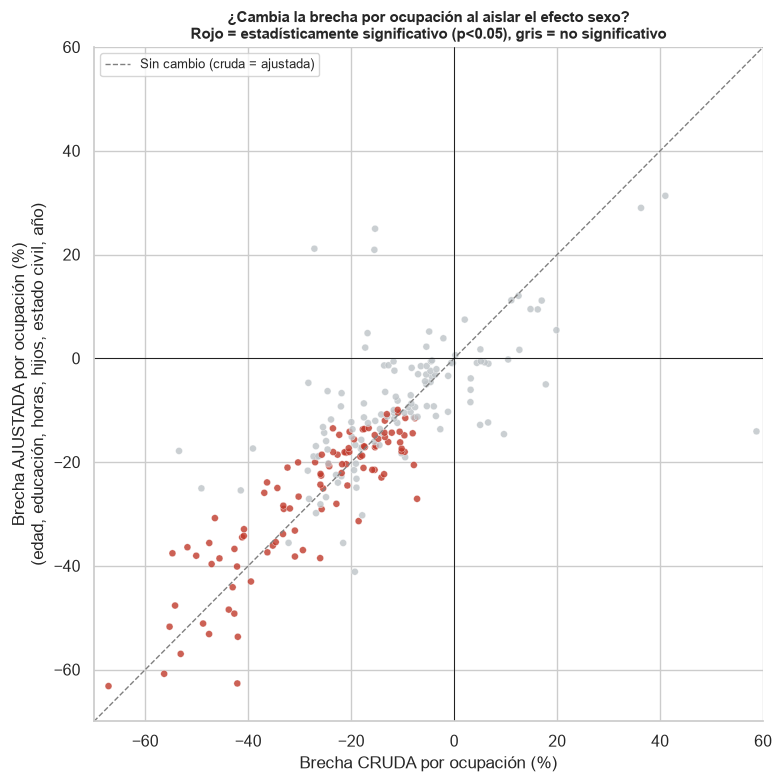

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
colores_sig = df_ajustado['significativo'].map({True: '#c0392b', False: '#bdc3c7'})
ax.scatter(df_ajustado['brecha_cruda_pct'], df_ajustado['gap_ajustado_pct'],
           c=colores_sig, s=25, alpha=0.8, edgecolor='white', linewidth=0.3)
lims = [-70, 60]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1, label='Sin cambio (cruda = ajustada)')
ax.axhline(0, color='black', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Brecha CRUDA por ocupación (%)')
ax.set_ylabel('Brecha AJUSTADA por ocupación (%)\n(edad, educación, horas, hijos, estado civil, año)')
ax.set_title('¿Cambia la brecha por ocupación al aislar el efecto sexo?\nRojo = estadísticamente significativo (p<0.05), gris = no significativo',
             fontsize=11, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/ranking_ajustado_vs_crudo.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación

Aislando el efecto sexo lo más posible (229 ocupaciones exactas, controlando edad, educación, horas, hijos, estado civil y año en un solo modelo): **102 de 229 ocupaciones (44.5%) muestran una brecha ajustada estadísticamente significativa (p<0.05) — y las 102 son en contra de las mujeres. Ninguna ocupación muestra una brecha significativamente favorable a mujeres** una vez controlado todo lo demás.

El resultado **resiste la corrección por comparaciones múltiples**: con 229 contrastes simultáneos se esperarían ~11 falsos positivos por azar a p<0.05, pero 76 ocupaciones sobreviven la corrección FDR de Benjamini-Hochberg (q<0.05) y 33 sobreviven incluso Bonferroni, el criterio más conservador disponible — y en todos los casos, la totalidad de las significativas es en contra de las mujeres.

Esto es clave para leer el ranking crudo de la sección 3: ahí, ocupaciones como "Joyeros" (+58.7%), "Músicos" (+41.0%) o "Traductores" (+36.3%) aparecían con brechas grandes a favor de mujeres. En el modelo ajustado, **ninguna de ellas es estadísticamente significativa** (p>0.2 en todos los casos) — son muestras chicas (n entre 55 y 148) y el "efecto favorable" no se distingue del azar una vez que se contabiliza la incertidumbre de la estimación. En cambio, del lado negativo, la mayoría de las brechas grandes (cosmetólogos, avicultores, artesanos textiles, costureros, etc.) **sí son significativas**, con muestras más grandes y errores estándar más chicos.

La correlación entre brecha cruda y ajustada es 0.79 — el orden general se mantiene, pero el promedio baja levemente (-17.7% cruda a -16.7% ajustada): parte de la brecha cruda en ocupaciones específicas se explica por composición (más mujeres solteras, más años de estudio distintos, etc. dentro de esa ocupación), aunque el grueso de la brecha por ocupación sigue intacto después de aislar el sexo.

**Conclusión práctica:** el ranking de la sección 3 es útil para explorar, pero el ranking de esta sección 7 es el que responde con más rigor "¿en qué ocupación específica hay evidencia sólida de brecha salarial de género?" — y la respuesta honesta es que la evidencia sólida apunta consistentemente en una sola dirección: en contra de las mujeres.

## Conclusiones

1. **La brecha no desaparece ni siquiera dentro de la misma ocupación de 4 dígitos** — persiste en médicos, enfermeros y técnicos por igual, aunque con magnitudes distintas
2. **Comparar controlando por ocupación amplia vs. granular, con los mismos datos**, aísla el efecto puro de la granularidad — la sección 2 cuantifica exactamente cuánto de la brecha "no explicada" de los notebooks 06-07 se debía a que el 1 dígito no distinguía especialidades dentro de "Profesionales" y categorías similares
3. **El ranking de controles (sección 4) muestra que, incluso con el control más fino disponible, la mayoría de la brecha sigue sin explicarse** — la ocupación granular es el mayor factor de composición identificado, pero está lejos de cerrar la brecha por sí sola
4. **Hijos y estado civil (secciones 5-6), medidos con una pregunta directa de CASEN** (no una proxy de composición del hogar como en el notebook 07): a diferencia de la ESI, aquí la interacción mujer×hijos **sí es significativa** (-9.7%, p<0.001) incluso controlando la ocupación exacta — hay una penalización por maternidad real, concentrada en mujeres casadas/convivientes. Pero en la descomposición de Oaxaca-Blinder esto no reduce el "no explicado" (sube de 77.8% a 82.2%): hombres y mujeres no difieren tanto en composición familiar, así que el efecto es de *retorno* (mismo hijo, mismo estado civil, distinto impacto salarial), no de composición — queda del lado del residuo, no explicándolo
5. **Al aislar el efecto sexo al máximo, ocupación por ocupación (sección 7)**: 102 de 229 ocupaciones muestran brecha estadísticamente significativa, y las 102 son en contra de mujeres — cero ocupaciones muestran una brecha significativa a favor de ellas (robusto a comparaciones múltiples: 76 sobreviven FDR y 33 incluso Bonferroni, todas en contra). Las brechas "favorables a mujeres" del ranking crudo (sección 3) no resisten el control de incertidumbre estadística
6. **Límite de esta extensión:** no se pudo incluir 2017 (usa CIUO-88, no CIUO-08) ni comparar directamente con los coeficientes de ESI (fuente de datos, años y definición de ingreso distintos) — la comparación rigurosa es la interna de este notebook, no un cruce entre repositorios
7. **Complementa** a `empleabilidad-formacion-casen-chile`: mismo tipo de hallazgo (agregar granularidad revela heterogeneidad oculta), ahora aplicado a la brecha salarial de género en vez de a la empleabilidad por área de formación